TASK 3: Real-world data aquisition and handling

In [1]:
from datetime import datetime
import time

import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
import scipy
from matplotlib.ticker import MaxNLocator
from datetime import timedelta

# Import Pandas only for reading Watch CSV File and for plotting description in Q1
import pandas as pd


In [2]:
def load_bp_csv(filename, start_datetime):
    test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
    test = test.drop(0)
    test = test.drop(test.columns[3], axis=1)  # Drop the first column
    test = test.rename(columns={'CH9': 'ecg', 'CH1': 'ppg'})
    test['ppg'] = pd.to_numeric(test['ppg'], errors='coerce')
    # if 'min' in test.columns, create new milli sec column
    if 'min' in test.columns:
        # Convert 'min' to milliseconds
        test['time_ms'] = test['min'] * 60 * 1000
    else:
        test = test.rename(columns={'milliSec': 'time_ms'})
    test['ecg'] = pd.to_numeric(test['ecg'], errors='coerce')
    test['timestamp'] = pd.to_datetime(start_datetime) + pd.to_timedelta(test['time_ms'], unit='ms')
    return test


def load_watch_ecg(filename):
    df = pd.read_csv(filename, skiprows=2)
    df = df[['Timestamp', 'ECG data']].dropna()
    df.rename(columns={'Timestamp': 'timestamp', 'ECG data': 'ecg'}, inplace=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['ecg'] = pd.to_numeric(df['ecg'], errors='coerce')
    df = df.dropna()

    # Convert to seconds
    df['time_ms'] = (df['timestamp'] - df['timestamp'].iloc[0])
    return df


def load_watch_data(ecg_file, ppg_file):
    ecg_df = pd.read_csv(ecg_file, skiprows=2)
    ppg_df = pd.read_csv(ppg_file, skiprows=2)

    # Rename columns for clarity
    ecg_df.rename(columns={'Timestamp': 'timestamp', 'ECG data': 'ecg'}, inplace=True)
    ppg_df.rename(columns={'PPG Timestamp': 'timestamp', 'PPG data': 'ppg'}, inplace=True)

    latest_start_time = max(ecg_df['timestamp'].iloc[0], ppg_df['timestamp'].iloc[0])
    earliest_end_time = min(ecg_df['timestamp'].iloc[-1], ppg_df['timestamp'].iloc[-1])

    # Filter data to the common time range
    ecg_df = ecg_df[(ecg_df['timestamp'] >= latest_start_time) & (ecg_df['timestamp'] <= earliest_end_time)]
    ppg_df = ppg_df[(ppg_df['timestamp'] >= latest_start_time) & (ppg_df['timestamp'] <= earliest_end_time)]

    # Drop all columns except timestamp, time_ms and ecg/ppg
    ppg_df = ppg_df.drop(columns=['ADXL Timestamp'])
    ecg_df = ecg_df.drop(columns=['Seq No.'])
    # Merge ECG and PPG based on the millisecond given
    merged_df = pd.merge_asof(ecg_df.sort_values('timestamp'), ppg_df.sort_values('timestamp'), on='timestamp',
                              direction='nearest')

    merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'], unit='ms')
    return merged_df


def plot_watch_bp_ecg(watch_df, bp_data, start_time, end_time, dataset_name='Recording', vlines=[], vlines_name=[]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    watch_df.sort_values('timestamp', inplace=True)
    bp_data.sort_values('time_ms', inplace=True)

    # Select time frame to plot
    # Discard time frames that are not represented in both recordings
    latest_start_time = max(watch_df['timestamp'].iloc[0], bp_data['timestamp'].iloc[0])  # + timedelta(minutes=5)
    earliest_end_time = min(watch_df['timestamp'].iloc[-1], bp_data['timestamp'].iloc[-1])
    watch_df = watch_df[(watch_df['timestamp'] >= latest_start_time) & (watch_df['timestamp'] <= earliest_end_time)]
    watch_df = watch_df[(watch_df['timestamp'] >= start_time) & (watch_df['timestamp'] <= end_time)]
    bp_data = bp_data[(bp_data['timestamp'] >= latest_start_time) & (bp_data['timestamp'] <= earliest_end_time)]
    bp_data = bp_data[(bp_data['timestamp'] >= start_time) & (bp_data['timestamp'] <= end_time)]
    watch_df = watch_df.dropna()
    # Plot ECG from Watch
    ax1.plot(watch_df['timestamp'], watch_df['PPG'], label='PPG from Watch', color='blue')
    ax1.set_ylabel('ECG Amplitude')
    ax1.set_xlabel('Time')
    ax1.set_title(f'{dataset_name} - PPG Signal from Smartwatch')

    # Plot ECG from BioPac
    ax2.plot(bp_data['timestamp'], bp_data['ecg'], label='ECG from BioPac', color='orange')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('ECG Amplitude')
    ax2.set_title(f'{dataset_name} - ECG Signal from BioPac')
    ax1.legend()
    ax2.legend()
    for vline, vline_name in zip(vlines, vlines_name):
        ax1.axvline(x=vline, color='red', linestyle='--', label=vline_name)
        ax2.axvline(x=vline, color='red', linestyle='--', label=vline_name)
    #ax1.legend()
    #ax2.legend()
    plt.tight_layout()
    plt.show()
    bp_data['ppg']
    fig, ax3 = plt.subplots(figsize=(12, 4))
    ax3.plot(bp_data['timestamp'], bp_data['ppg'], label='PPG from BioPac', color='orange')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('ECG Amplitude')
    ax3.set_title(f'{dataset_name} - PPG Signal from BioPac')
    ax3.legend()
    for vline, vline_name in zip(vlines, vlines_name):
        ax3.axvline(x=vline, color='red', linestyle='--', label=vline_name)
    #ax3.legend()
    ax3.yaxis.set_major_locator(MaxNLocator(nbins=5))
    plt.tight_layout()
    plt.show()
    # plot xyz in one plot
    fig, ax4 = plt.subplots(figsize=(12, 4))
    ax4.plot(watch_df['timestamp'], watch_df['X'], label='X-axis', color='red')
    ax4.plot(watch_df['timestamp'], watch_df['Y'], label='Y-axis', color='green')
    ax4.plot(watch_df['timestamp'], watch_df['Z'], label='Z-axis', color='purple')
    ax4.set_xlabel('Time')
    ax4.set_ylabel('Acceleration')
    ax4.set_title(f'{dataset_name} - Acceleration Data from Watch')
    ax4.legend()
    for vline, vline_name in zip(vlines, vlines_name):
        ax4.axvline(x=vline, color='red', linestyle='--', label=vline_name)
    #ax4.legend()

    plt.tight_layout()
    plt.show()


def crop_window(data, start_time, end_time):
    data = data[(data['timestamp'] >= start_time) & (data['timestamp'] <= end_time)]
    return data

In [3]:
# Synchonization is done in here by adjusting the time difference from the logged time and the actual time from smartwatch
watch_rest = load_watch_data('data/assignment_3/Rest/ecg_2025_06_12_12_57_44ecgcentrifuge.csv',
                             'data/assignment_3/Rest/ppg_2025_06_12_12_57_44ppgcentrifuge.csv')
#2025-06-12 12:42:40.750
bp_rest = load_bp_csv('data/assignment_3/Rest/Biopac.txt',
                      start_datetime=datetime(2025, 6, 12, 10, 58, 20, 193000) - timedelta(seconds=2.9))

watch_stairs = load_watch_data('data/assignment_3/Stairs/ecg_2025_06_12_12_00_41ecgcentrifuge.csv',
                               'data/assignment_3/Stairs/ppg_2025_06_12_12_00_41ppgcentrifuge.csv')
#2025-06-12 12:01:19.122
bp_stairs = load_bp_csv('data/assignment_3/Stairs/Biopac.txt',
                        start_datetime=datetime(2025, 6, 12, 10, 1, 3, 334000) - timedelta(seconds=-1.65))

watch_workout = load_watch_data('data/assignment_3/Workout/ecg_2025_06_12_12_42_06ecgcentrifuge.csv',
                                'data/assignment_3/Workout/ppg_2025_06_12_12_42_06ppgcentrifuge.csv')
#2025-06-12 12:42:40.750
bp_workout = load_bp_csv('data/assignment_3/Workout/Biopac.txt',
                         start_datetime=datetime(2025, 6, 12, 10, 42, 40, 750000) - timedelta(seconds=.4))




/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/1424424884.py:2: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/1424424884.py:2: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/1424424884.py:2: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')


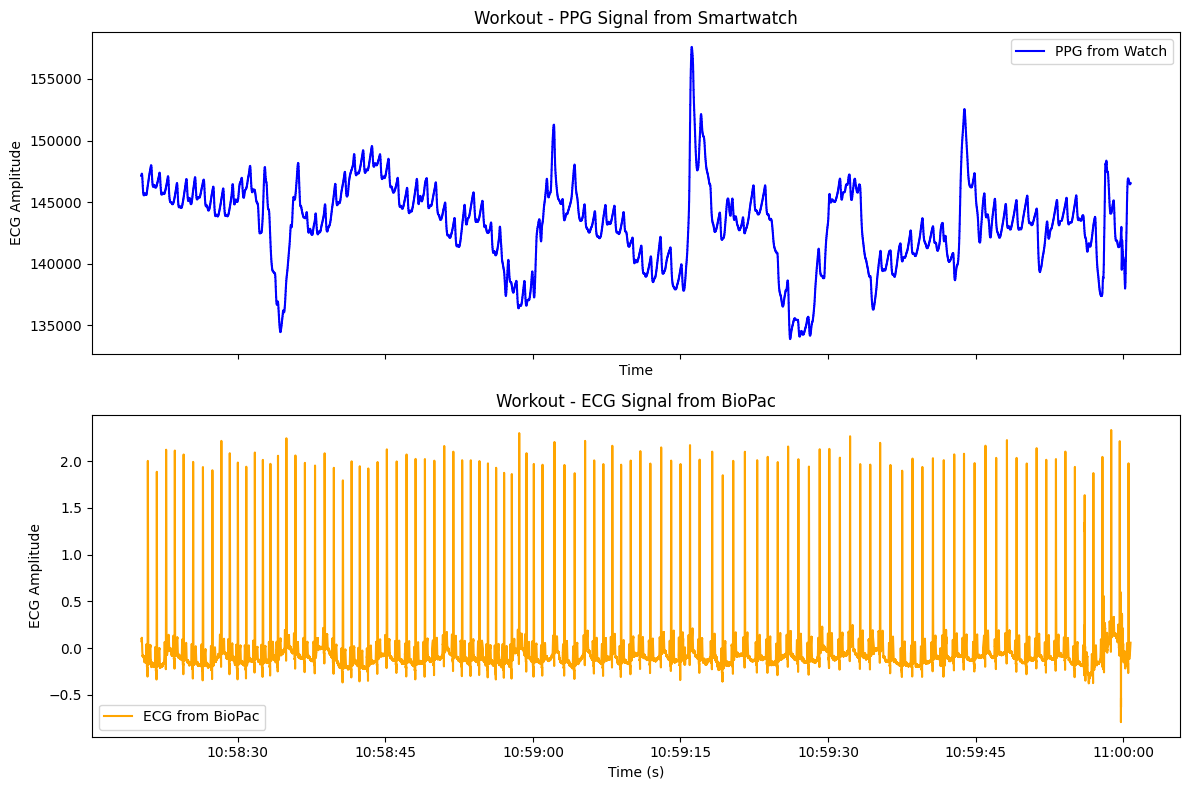

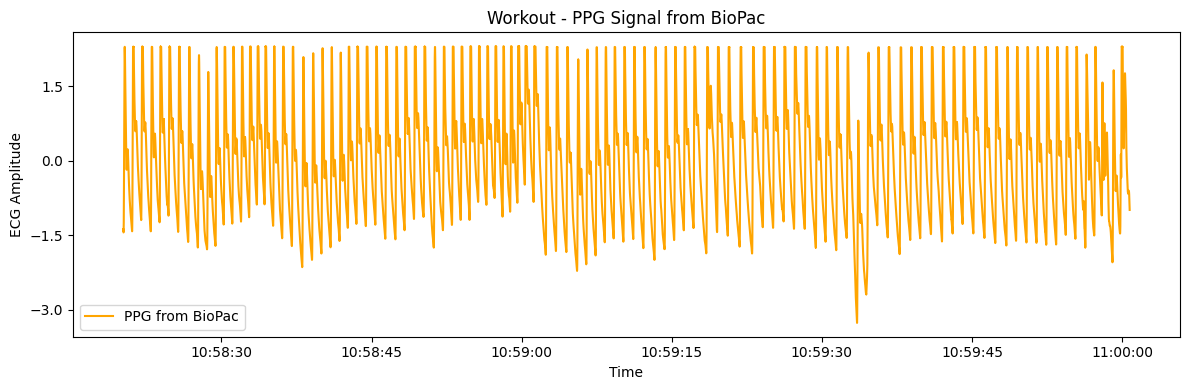

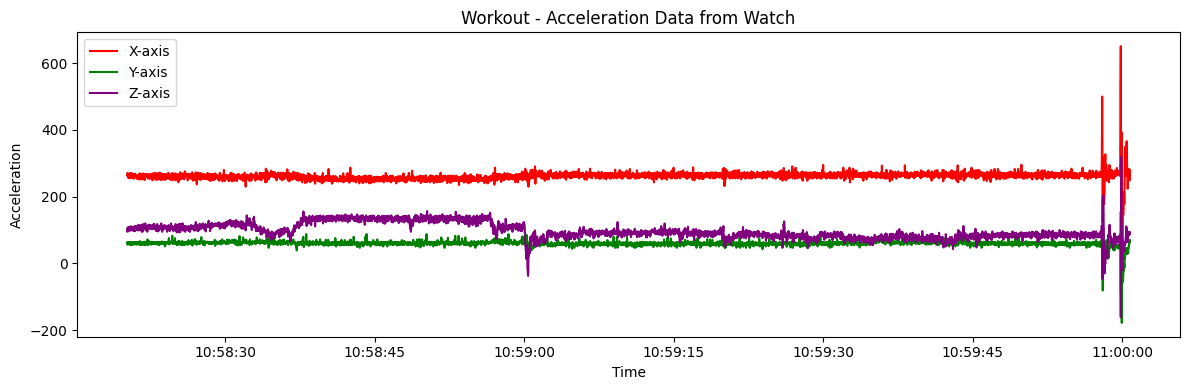

In [4]:
# Synchronization
plot_watch_bp_ecg(watch_rest, bp_rest,
                  start_time=datetime(2025, 6, 12, 10, 58, 20, 193000),
                  end_time=datetime(2025, 6, 12, 11, 0, 0, 750000),
                  dataset_name='Workout')

Initial Length of DF for 10 seconds of Stairs:  10076


/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/597480929.py:10: FutureWarning: 'L' is deprecated and will be removed in a future version, please use 'ms' instead.
  watch_df = watch_df.resample('1L').mean().interpolate(method='linear')


Length of DF after resampling and cropping:  10001


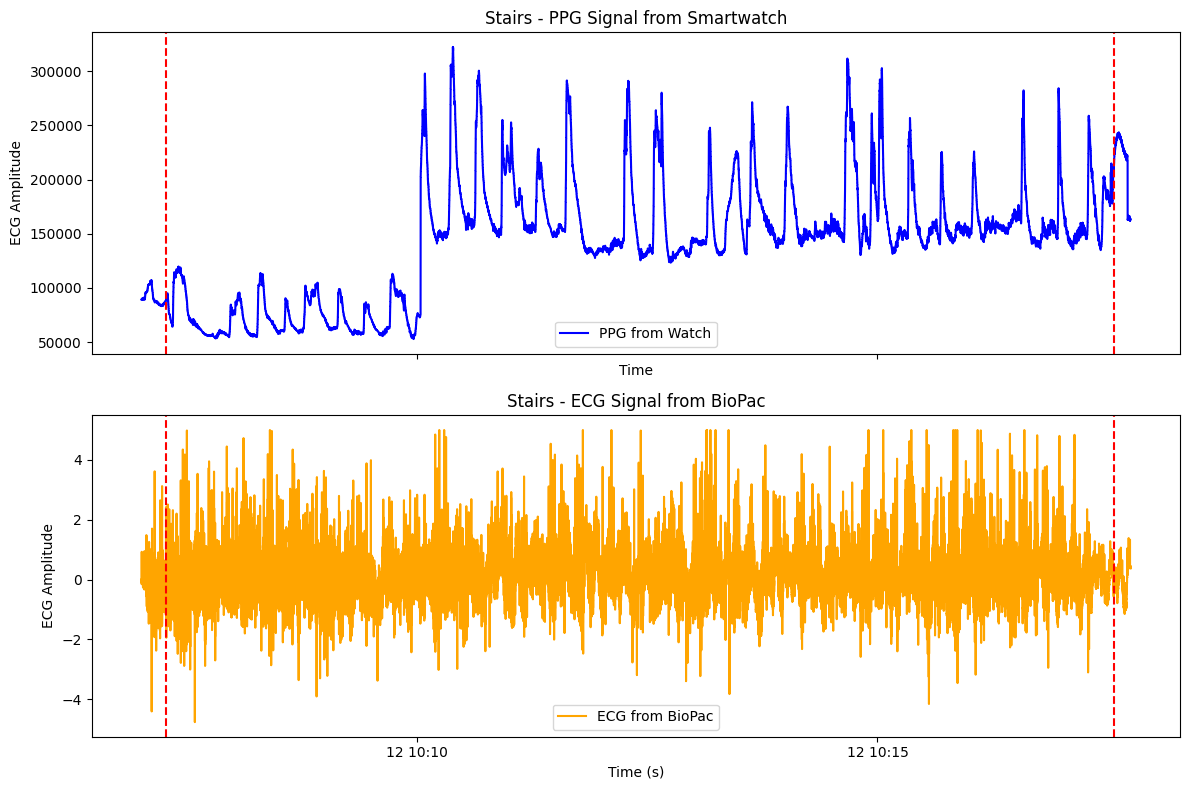

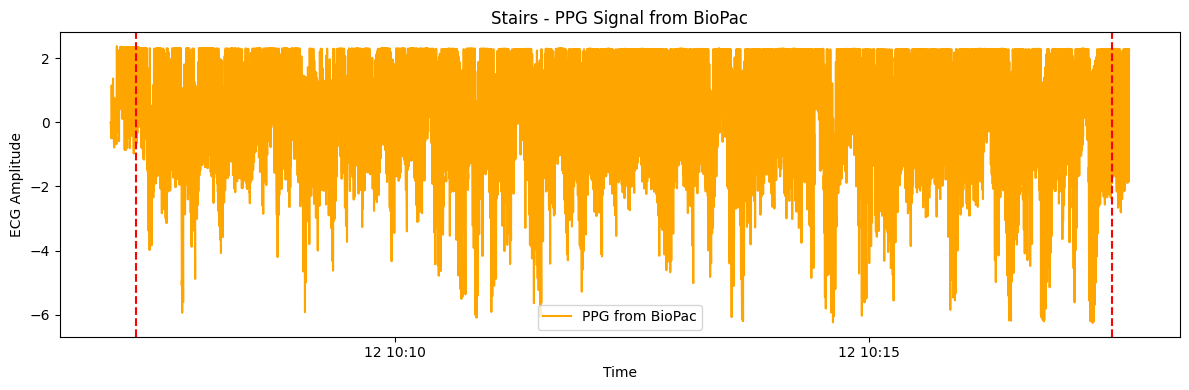

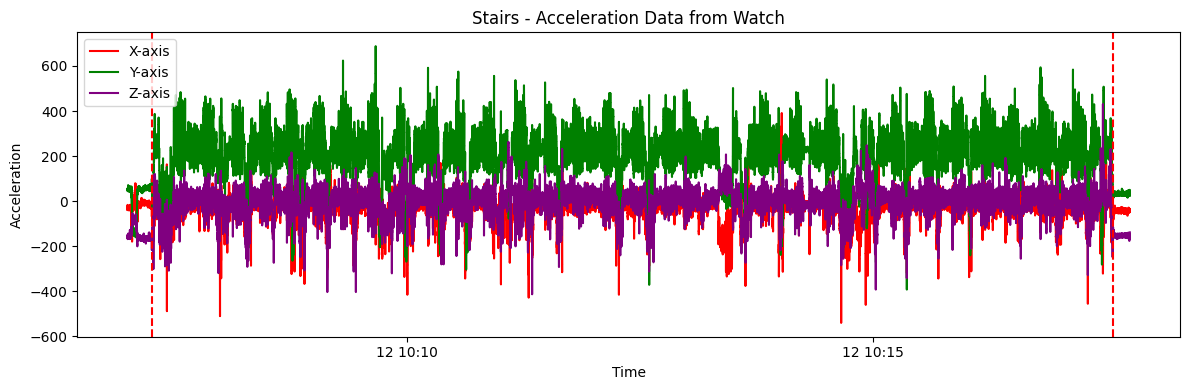

In [5]:
# Q1
cropped_stairs = crop_window(watch_stairs, start_time=datetime(2025, 6, 12, 10, 5, 0, 0),
                             end_time=datetime(2025, 6, 12, 10, 5, 10, 0))
print('Initial Length of DF for 10 seconds of Stairs: ', len(cropped_stairs))


# Resample to 1khz
def resample_watch_data(watch_df):
    watch_df = watch_df.set_index('timestamp')
    watch_df = watch_df.resample('1L').mean().interpolate(method='linear')
    watch_df = watch_df.reset_index()
    return watch_df


watch_stairs_resampled = resample_watch_data(watch_stairs)
cropped_stairs_2 = crop_window(watch_stairs_resampled, start_time=datetime(2025, 6, 12, 10, 5, 0, 0),
                               end_time=datetime(2025, 6, 12, 10, 5, 10, 0))

print('Length of DF after resampling and cropping: ', len(cropped_stairs_2))

# Plot the resampled data
#!!! There is a couple of seconds before and after exercise, to show the difference
plot_watch_bp_ecg(watch_stairs_resampled, bp_stairs,
                  start_time=datetime(2025, 6, 12, 10, 7, 0, 0),
                  end_time=datetime(2025, 6, 12, 10, 17, 45, 0),
                  dataset_name='Stairs',
                  vlines=[datetime(2025, 6, 12, 10, 7, 16, 0),
                          datetime(2025, 6, 12, 10, 17, 34, 0)],
                  vlines_name=['Start of Workout', 'End of Workout'])

Initial Length of DF for 10 seconds of Workout:  1007
Length of DF after resampling and cropping:  1001


/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/597480929.py:10: FutureWarning: 'L' is deprecated and will be removed in a future version, please use 'ms' instead.
  watch_df = watch_df.resample('1L').mean().interpolate(method='linear')


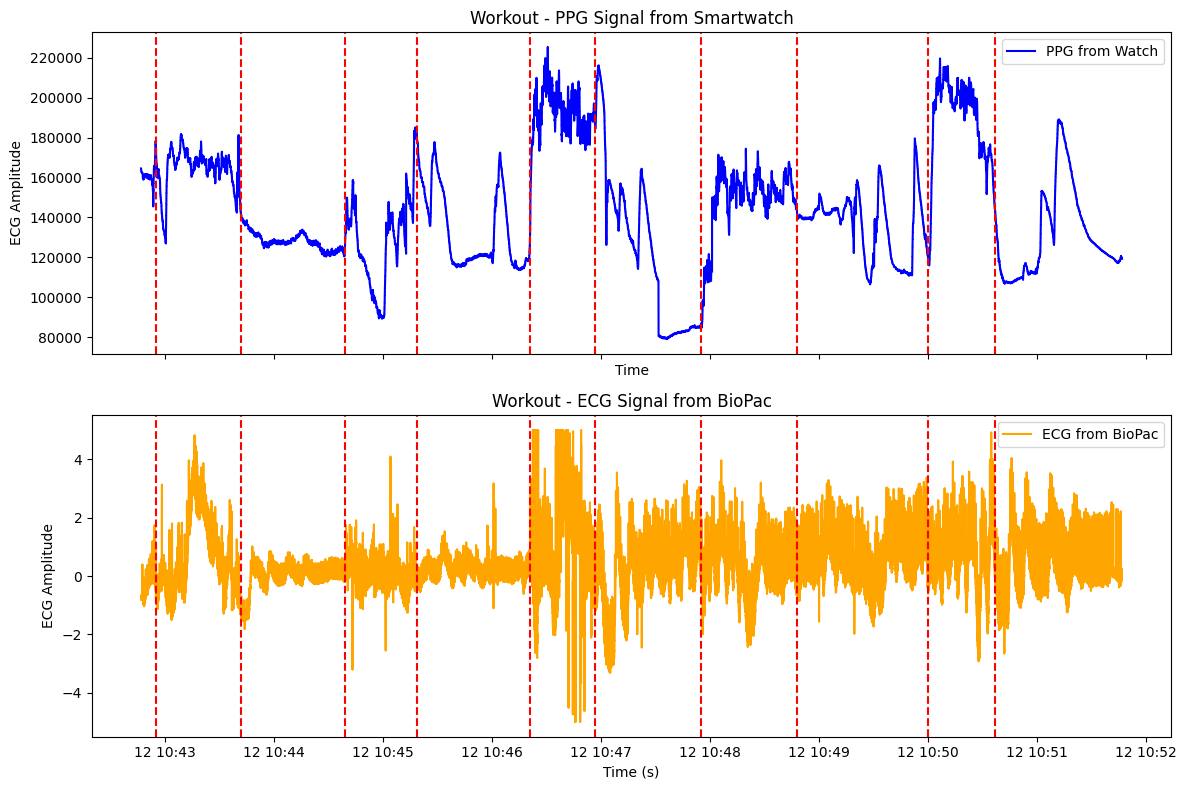

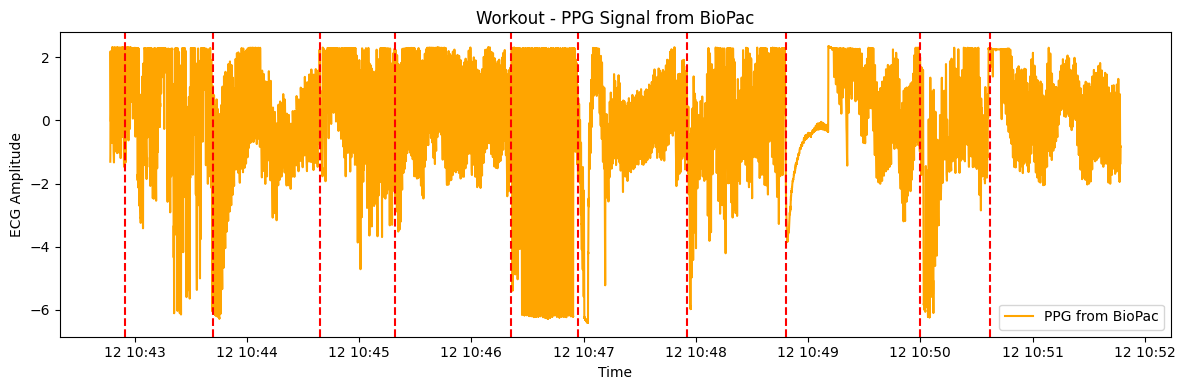

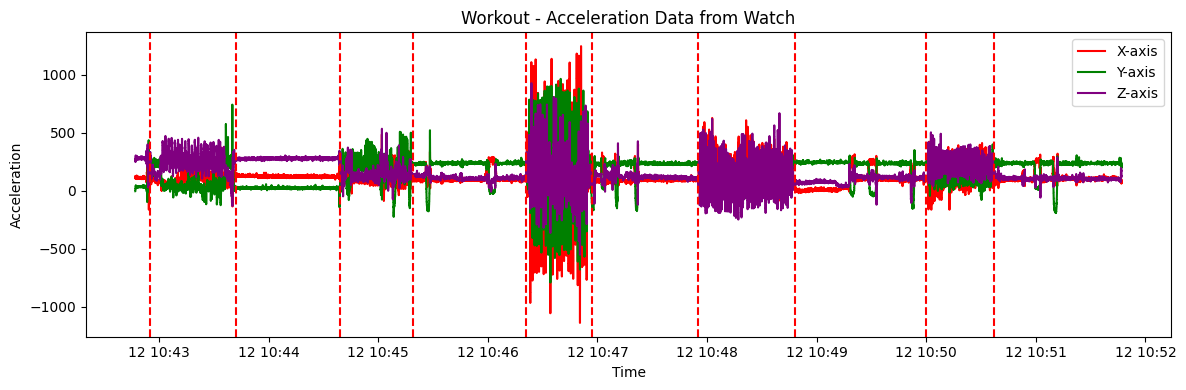

In [6]:
# Q2
cropped_workout = crop_window(watch_workout, start_time=datetime(2025, 6, 12, 10, 43, 40, 0),
                              end_time=datetime(2025, 6, 12, 10, 43, 41, 0))
print('Initial Length of DF for 10 seconds of Workout: ', len(cropped_workout))
watch_workout_resampled = resample_watch_data(watch_workout)
cropped_workout_2 = crop_window(watch_workout_resampled, start_time=datetime(2025, 6, 12, 10, 43, 40, 0),
                                end_time=datetime(2025, 6, 12, 10, 43, 41, 0))
print('Length of DF after resampling and cropping: ', len(cropped_workout_2))

# Plot the resampled data
plot_watch_bp_ecg(watch_workout, bp_workout,
                  start_time=datetime(2025, 6, 12, 10, 42, 47, 0),
                  end_time=datetime(2025, 6, 12, 11, 43, 00, 0),
                  dataset_name='Workout',
                  vlines=[
                      datetime(2025, 6, 12, 10, 42, 55, 0),
                      datetime(2025, 6, 12, 10, 43, 42, 0),

                      datetime(2025, 6, 12, 10, 44, 39, 0),
                      datetime(2025, 6, 12, 10, 45, 19, 0),

                      datetime(2025, 6, 12, 10, 46, 21, 0),
                      datetime(2025, 6, 12, 10, 46, 57, 0),

                      datetime(2025, 6, 12, 10, 47, 55, 0),
                      datetime(2025, 6, 12, 10, 48, 48, 0),

                      datetime(2025, 6, 12, 10, 50, 00, 0),
                      datetime(2025, 6, 12, 10, 50, 37, 0)],
                  vlines_name=['Transition'] * 10
                  )


In [7]:
# Q3

def compute_heart_rate_metrics(ecg_df, sampling_rate=1000):
    # Schritt 1: R-Peak-Detection mit neurokit2
    ecg_signal = ecg_df['ecg'].fillna(method='ffill').fillna(method='bfill')
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_rate)
    _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)
    rpeaks_indices = rpeaks['ECG_R_Peaks']

    # Schritt 2: Instantane Herzfrequenz (ohne Toolbox)
    rr_intervals = np.diff(ecg_df['timestamp'].values[rpeaks_indices]) / np.timedelta64(1, 's')
    inst_hr = 60 / rr_intervals
    inst_hr_time = ecg_df['timestamp'].values[rpeaks_indices][1:]

    inst_hr_df = pd.DataFrame({'timestamp': inst_hr_time, 'hr': inst_hr})

    # Schritt 3: Geglättete HR (Median über 10s mit 1s Schrittweite)
    window_size = 10
    step_size = 1
    start_time = inst_hr_df['timestamp'].min()
    end_time = inst_hr_df['timestamp'].max()

    smoothed_hr = []
    times = []

    current = start_time
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)

        hr_vals = inst_hr_df[(inst_hr_df['timestamp'] >= current) &
                             (inst_hr_df['timestamp'] < window_end)]['hr']
        if len(hr_vals) > 0:
            smoothed_hr.append(np.median(hr_vals))
            times.append(middle)
        current += timedelta(seconds=step_size)

    smoothed_hr_df = pd.DataFrame({'timestamp': times, 'smoothed_hr': smoothed_hr})

    return inst_hr_df, smoothed_hr_df, ecg_df, rpeaks_indices


def plot_ecg_with_rpeaks(ecg_df, rpeaks_indices, title, start_time, end_time):
    segment = ecg_df[(ecg_df['timestamp'] >= start_time) & (ecg_df['timestamp'] <= end_time)].copy()
    segment_indices = segment.index

    rpeaks_in_segment = [i for i in rpeaks_indices if i in segment_indices]

    plt.figure(figsize=(12, 4))
    plt.plot(segment['timestamp'], segment['ecg'], label='ECG')
    plt.plot(ecg_df['timestamp'].iloc[rpeaks_in_segment],
             ecg_df['ecg'].iloc[rpeaks_in_segment], 'ro', label='R-peaks')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_hr(inst_hr_df, smoothed_hr_df, title):
    plt.figure(figsize=(12, 4))
    plt.plot(inst_hr_df['timestamp'], inst_hr_df['hr'], label='Instant HR', alpha=0.7)
    plt.plot(smoothed_hr_df['timestamp'], smoothed_hr_df['smoothed_hr'], label='Smoothed HR', linewidth=2)
    plt.title(title)
    plt.ylabel('Heart Rate (bpm)')
    plt.xlabel('Time')
    plt.legend()
    plt.tight_layout()
    plt.show()


/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/574441821.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ecg_signal = ecg_df['ecg'].fillna(method='ffill').fillna(method='bfill')


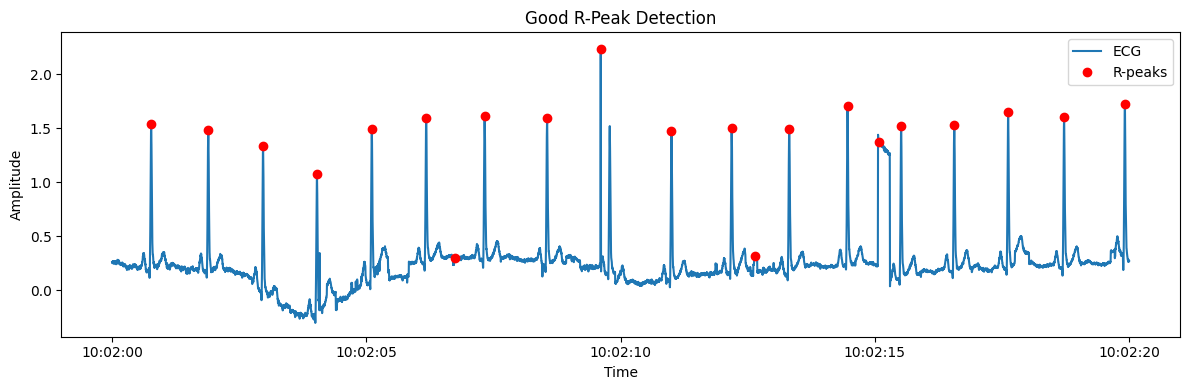

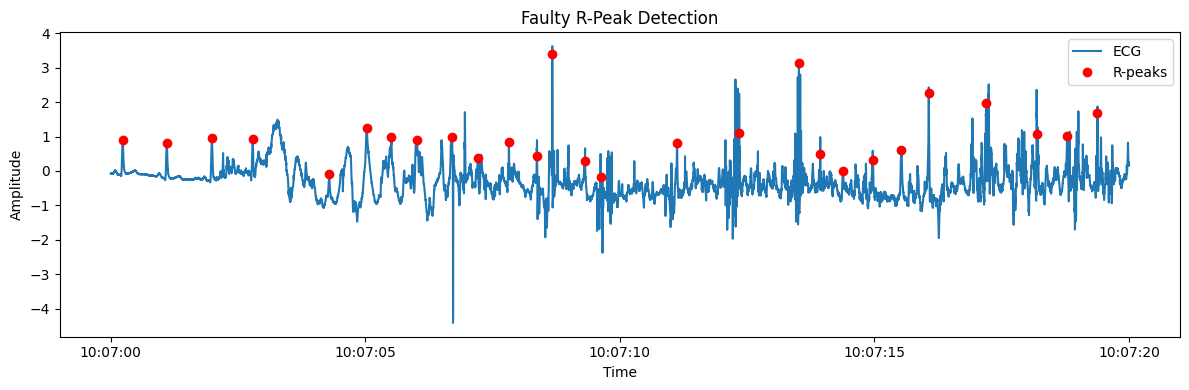

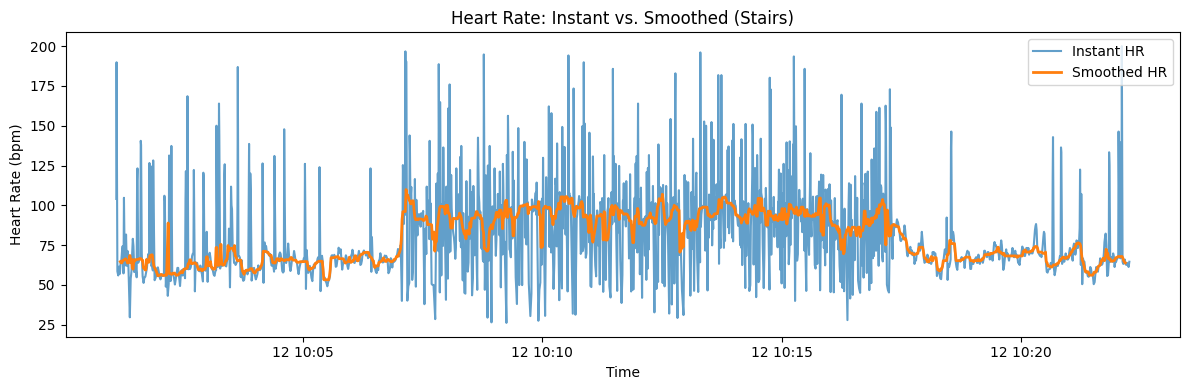

In [8]:
# Q3 
# Schritt 1: Auf eine Biopac-ECG-Messung anwenden (z. B. "Stairs")
inst_hr_df, smoothed_hr_df, ecg_clean_df, rpeaks = compute_heart_rate_metrics(bp_stairs)

# Schritt 2: 20s Segment – wo es gut funktioniert hat (z. B. manuell wählen)
plot_ecg_with_rpeaks(ecg_clean_df, rpeaks,
                     title="Good R-Peak Detection",
                     start_time=datetime(2025, 6, 12, 10, 2, 0),
                     end_time=datetime(2025, 6, 12, 10, 2, 20))

# Schritt 3: 20s Segment – wo es schlecht funktioniert hat (manuell wählen)
plot_ecg_with_rpeaks(ecg_clean_df, rpeaks,
                     title="Faulty R-Peak Detection",
                     start_time=datetime(2025, 6, 12, 10, 7, 0),
                     end_time=datetime(2025, 6, 12, 10, 7, 20))

# Schritt 4: Vergleich der Herzfrequenz-Verläufe
plot_hr(inst_hr_df, smoothed_hr_df, title="Heart Rate: Instant vs. Smoothed (Stairs)")


In [9]:
def compute_heart_rate_metrics_mean(ecg_df, sampling_rate=1000):
    import neurokit2 as nk

    # Schritt 1: R-Peak-Erkennung mit neurokit2
    ecg_signal = ecg_df['ecg'].fillna(method='ffill').fillna(method='bfill')
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_rate)
    _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)
    rpeaks_indices = rpeaks['ECG_R_Peaks']

    # Schritt 2: Instantane Herzfrequenz berechnen (60 / RR-Intervall in s)
    rr_intervals = np.diff(ecg_df['timestamp'].values[rpeaks_indices]) / np.timedelta64(1, 's')
    inst_hr = 60 / rr_intervals
    inst_hr_time = ecg_df['timestamp'].values[rpeaks_indices][1:]

    inst_hr_df = pd.DataFrame({'timestamp': inst_hr_time, 'hr': inst_hr})

    # Schritt 3: Smoothed HR (Mittelwert über 10s, 1s Schritt)
    window_size = 10
    step_size = 1
    start_time = inst_hr_df['timestamp'].min()
    end_time = inst_hr_df['timestamp'].max()

    smoothed_hr = []
    times = []

    current = start_time
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)

        hr_vals = inst_hr_df[(inst_hr_df['timestamp'] >= current) &
                             (inst_hr_df['timestamp'] < window_end)]['hr']
        if len(hr_vals) > 0:
            smoothed_hr.append(np.mean(hr_vals))
            times.append(middle)
        current += timedelta(seconds=step_size)

    smoothed_hr_df = pd.DataFrame({'timestamp': times, 'smoothed_hr': smoothed_hr})

    return inst_hr_df, smoothed_hr_df, ecg_df, rpeaks_indices


/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/146212171.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ecg_signal = ecg_df['ecg'].fillna(method='ffill').fillna(method='bfill')


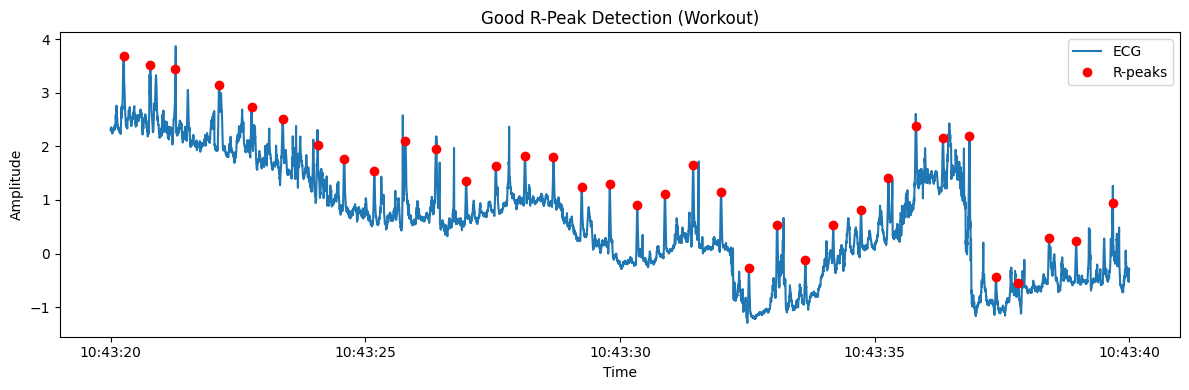

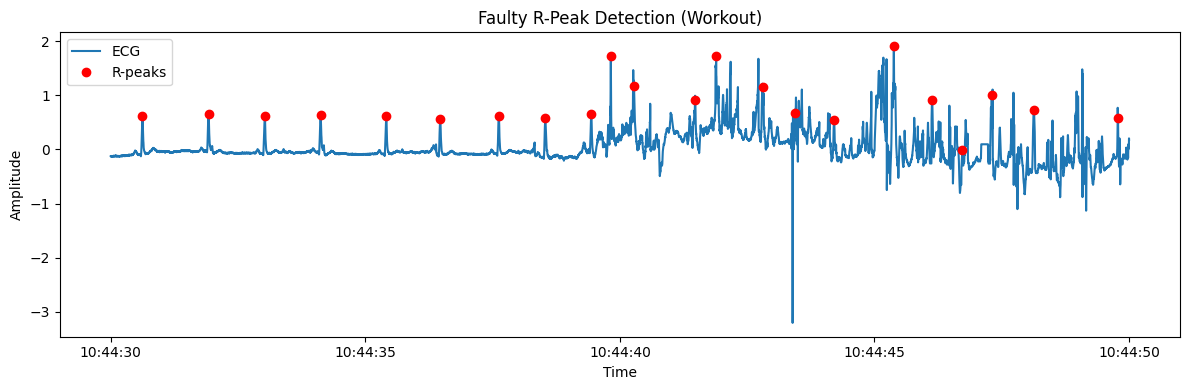

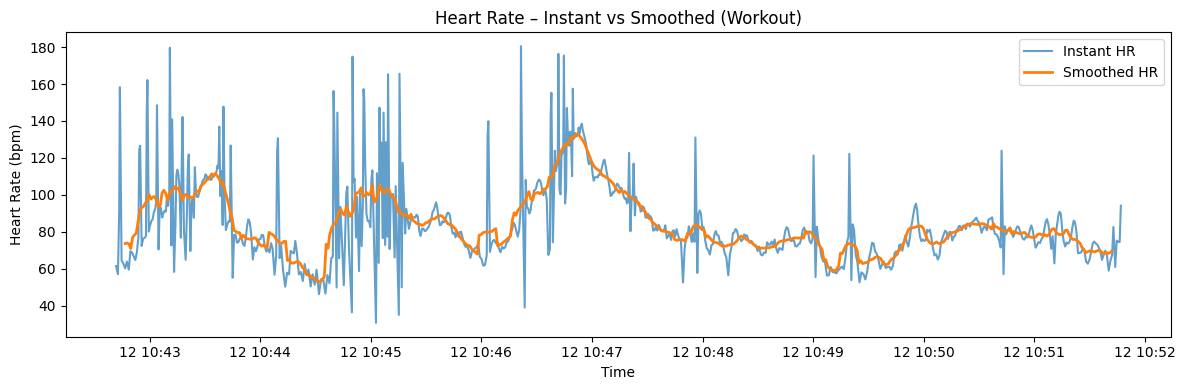

In [10]:
# Q4
# Berechne Herzfrequenzen
inst_hr_df, smoothed_hr_df, ecg_df, rpeaks = compute_heart_rate_metrics_mean(bp_workout)

# Plot: gutes Segment (z. B. 10:43:20–10:43:40)
plot_ecg_with_rpeaks(ecg_df, rpeaks,
                     title="Good R-Peak Detection (Workout)",
                     start_time=datetime(2025, 6, 12, 10, 43, 20),
                     end_time=datetime(2025, 6, 12, 10, 43, 40))

# Plot: schlechtes Segment (z. B. 10:44:30–10:44:50)
plot_ecg_with_rpeaks(ecg_df, rpeaks,
                     title="Faulty R-Peak Detection (Workout)",
                     start_time=datetime(2025, 6, 12, 10, 44, 30),
                     end_time=datetime(2025, 6, 12, 10, 44, 50))

# Plot: Herzfrequenzverlauf
plot_hr(inst_hr_df, smoothed_hr_df, title="Heart Rate – Instant vs Smoothed (Workout)")



In [11]:
# Q5
def compute_ppg_hr_metrics(ppg_df, sampling_rate=1000):
    import neurokit2 as nk

    ppg_signal = ppg_df['PPG'].fillna(method='ffill').fillna(method='bfill')
    ppg_clean = nk.ppg_clean(ppg_signal, sampling_rate=sampling_rate)
    _, peaks = nk.ppg_peaks(ppg_clean, sampling_rate=sampling_rate)
    peak_indices = peaks['PPG_Peaks']

    # Instantane Herzfrequenz
    timestamps = ppg_df['timestamp'].values
    rr_intervals = np.diff(timestamps[peak_indices]) / np.timedelta64(1, 's')
    hr = 60 / rr_intervals
    hr_time = timestamps[peak_indices][1:]

    inst_hr_df = pd.DataFrame({'timestamp': hr_time, 'hr': hr})

    # Smoothed HR: Mean in 10s window, 1s slide
    window_size = 10
    step_size = 1
    start_time = inst_hr_df['timestamp'].min() + timedelta(seconds=5)
    end_time = inst_hr_df['timestamp'].max()

    smoothed_hr, times = [], []
    current = start_time
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)
        hr_vals = inst_hr_df[(inst_hr_df['timestamp'] >= current) &
                             (inst_hr_df['timestamp'] < window_end)]['hr']
        if len(hr_vals) > 0:
            smoothed_hr.append(np.mean(hr_vals))
            times.append(middle)
        current += timedelta(seconds=step_size)

    smoothed_df = pd.DataFrame({'timestamp': times, 'smoothed_hr': smoothed_hr})
    return inst_hr_df, smoothed_df, ppg_df, peak_indices


def plot_ppg_with_peaks(ppg_df, peak_indices, title, start_time, end_time):
    segment = ppg_df[(ppg_df['timestamp'] >= start_time) & (ppg_df['timestamp'] <= end_time)]
    segment_indices = segment.index
    peaks_in_segment = [i for i in peak_indices if i in segment_indices]

    plt.figure(figsize=(12, 4))
    plt.plot(segment['timestamp'], segment['PPG'], label='PPG')
    plt.plot(ppg_df['timestamp'].iloc[peaks_in_segment],
             ppg_df['PPG'].iloc[peaks_in_segment], 'ro', label='Peaks')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('PPG Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_ppg_hr(inst_hr_df, smoothed_hr_df, title):
    plt.figure(figsize=(12, 4))
    plt.plot(inst_hr_df['timestamp'], inst_hr_df['hr'], label='Instant HR', alpha=0.6)
    plt.plot(smoothed_hr_df['timestamp'], smoothed_hr_df['smoothed_hr'],
             label='Smoothed HR (10s mean)', linewidth=2)
    plt.title(title)
    plt.ylabel("Heart Rate (bpm)")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    plt.show()



/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/2672511104.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ppg_signal = ppg_df['PPG'].fillna(method='ffill').fillna(method='bfill')


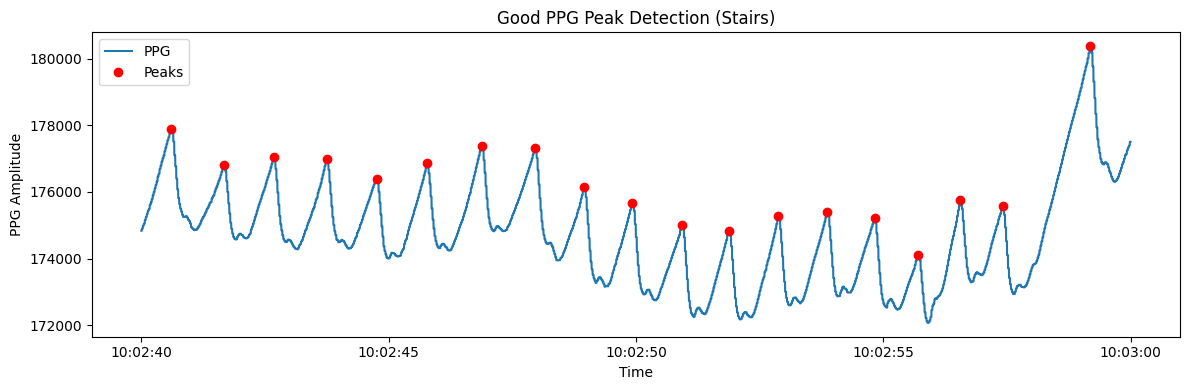

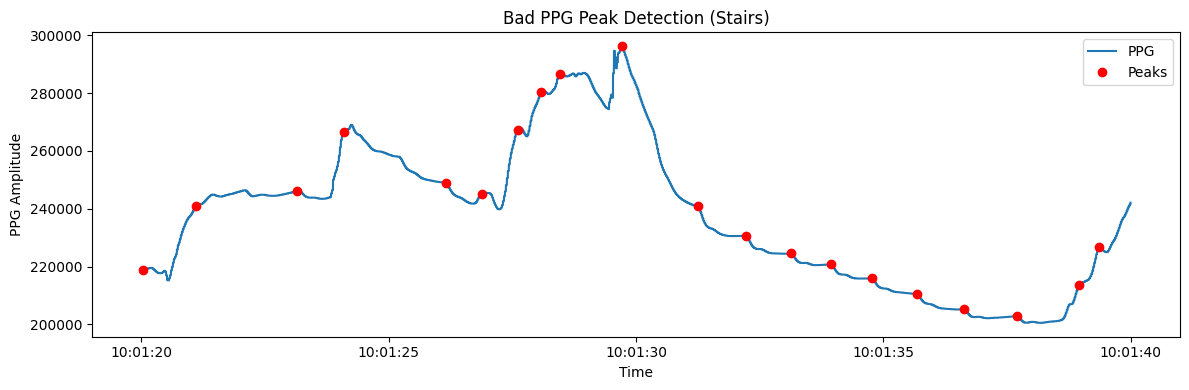

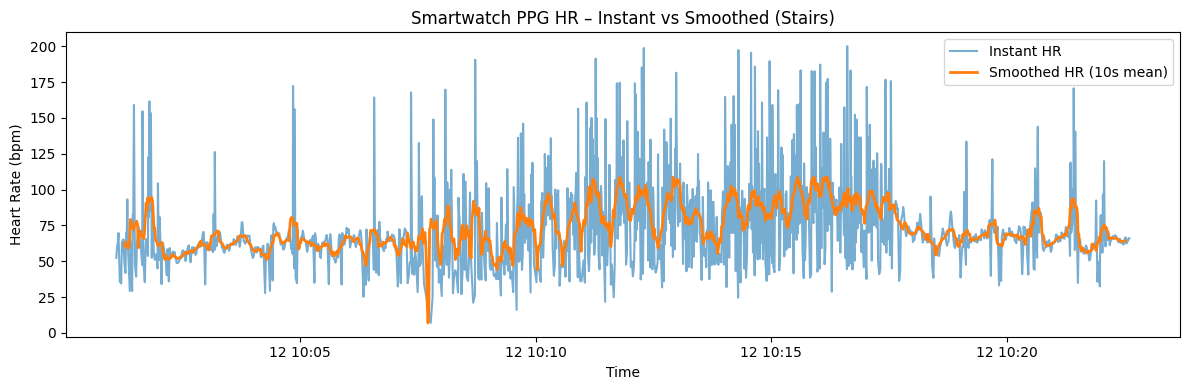

In [12]:
#Q5

# Herzfrequenz aus Smartwatch-PPG ("Stairs")
inst_hr_ppg, smoothed_hr_ppg, ppg_df, peak_idx = compute_ppg_hr_metrics(watch_stairs)

# Plot: gutes Segment
plot_ppg_with_peaks(ppg_df, peak_idx,
                    title="Good PPG Peak Detection (Stairs)",
                    start_time=datetime(2025, 6, 12, 10, 2, 40),
                    end_time=datetime(2025, 6, 12, 10, 3, 0))

# Plot: schlechtes Segment
plot_ppg_with_peaks(ppg_df, peak_idx,
                    title="Bad PPG Peak Detection (Stairs)",
                    start_time=datetime(2025, 6, 12, 10, 1, 20),
                    end_time=datetime(2025, 6, 12, 10, 1, 40))

# Plot: HR-Verlauf
plot_ppg_hr(inst_hr_ppg, smoothed_hr_ppg, title="Smartwatch PPG HR – Instant vs Smoothed (Stairs)")


In [13]:
watch_stairs

,timestamp,ecg,PPG,X,Y,Z
0,2025-06-12 10:01:03.670906006,24947,259866,-4,75,-159
1,2025-06-12 10:01:03.671906006,25014,259866,-4,75,-159
2,2025-06-12 10:01:03.672812988,25075,259866,-4,75,-159
3,2025-06-12 10:01:03.673812012,25123,259866,-4,75,-159
4,2025-06-12 10:01:03.674812988,25155,259866,-4,75,-159
...,...,...,...,...,...,...
1301935,2025-06-12 10:22:36.488187012,43201,87336,-16,80,-157
1301936,2025-06-12 10:22:36.489187988,45802,87336,-16,80,-157
1301937,2025-06-12 10:22:36.490187012,49607,87336,-16,80,-157
1301938,2025-06-12 10:22:36.491093994,53984,87336,-16,80,-157


/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/2672511104.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ppg_signal = ppg_df['PPG'].fillna(method='ffill').fillna(method='bfill')


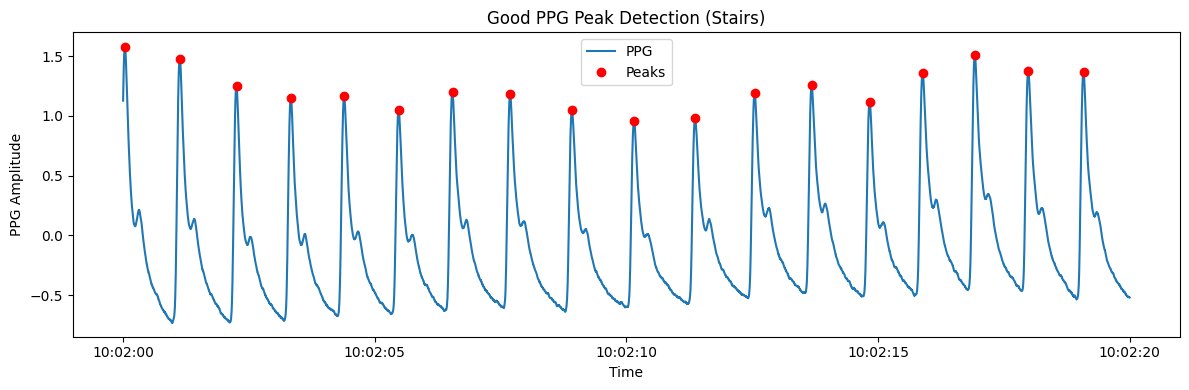

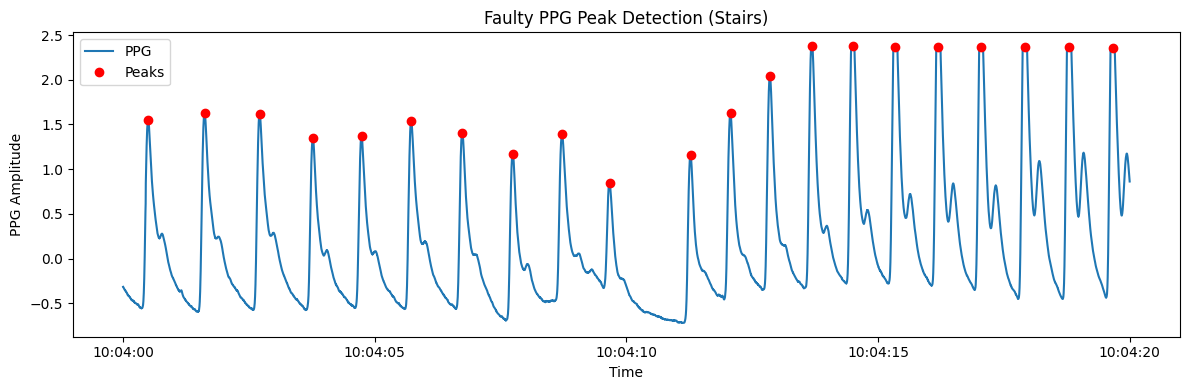

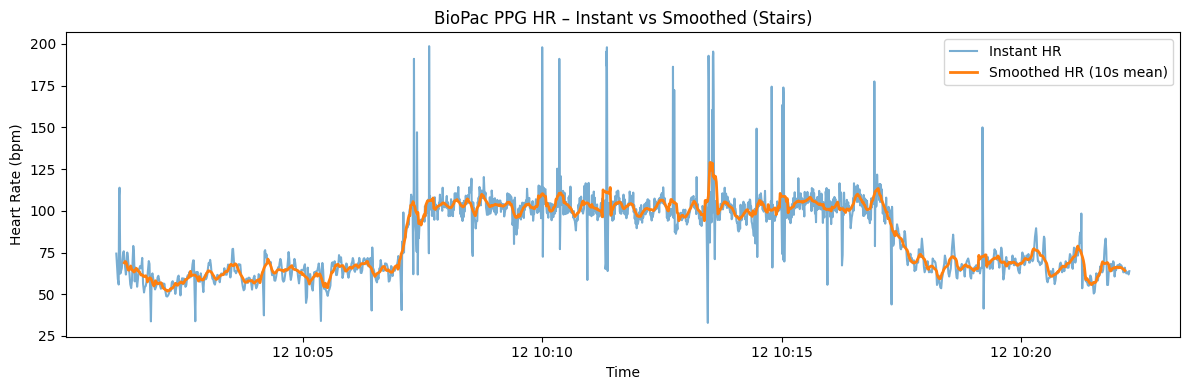

In [14]:
# Q6
# Herzfrequenz aus Smartwatch-PPG ("Stairs")
bp_stairs.rename(columns={'ppg': 'PPG'}, inplace=True)
inst_hr_ppg, smoothed_hr_ppg, ppg_df, peak_idx = compute_ppg_hr_metrics(bp_stairs)

# Plot: gutes Segment
plot_ppg_with_peaks(ppg_df, peak_idx,
                    title="Good PPG Peak Detection (Stairs)",
                    start_time=datetime(2025, 6, 12, 10, 2, 0),
                    end_time=datetime(2025, 6, 12, 10, 2, 20))

# Plot: schlechtes Segment
plot_ppg_with_peaks(ppg_df, peak_idx,
                    title="Faulty PPG Peak Detection (Stairs)",
                    start_time=datetime(2025, 6, 12, 10, 4, 0),
                    end_time=datetime(2025, 6, 12, 10, 4, 20))

# Plot: HR-Verlauf
plot_ppg_hr(inst_hr_ppg, smoothed_hr_ppg, title="BioPac PPG HR – Instant vs Smoothed (Stairs)")


In [15]:
# Q7 Using Workout Data since it is more clear
def butterworth_highpass_filter(signal, cutoff_freq, fs=1000, order=2):
    """
    Simple implementation of a Butterworth high-pass filter using bilinear transform method.
    """
    # Normalize frequency
    wc = 2 * np.pi * cutoff_freq
    T = 1 / fs
    k = wc / np.tan(wc * T / 2)

    # Coefficients for second-order Butterworth HPF
    a0 = k**2 + np.sqrt(2)*k + wc**2
    a1 = 2 * (wc**2 - k**2)
    a2 = k**2 - np.sqrt(2)*k + wc**2
    b0 = k**2
    b1 = -2 * k**2
    b2 = k**2

    # Normalize coefficients
    b = np.array([b0, b1, b2]) / a0
    a = np.array([1, a1/a0, a2/a0])

    # Apply filter (direct form II)
    y = np.zeros_like(signal)
    x = signal
    for n in range(2, len(signal)):
        y[n] = b[0]*x[n] + b[1]*x[n-1] + b[2]*x[n-2] - a[1]*y[n-1] - a[2]*y[n-2]
    return y

def detrend_signal(signal):
    """
    Simple linear detrending using numpy (alternative to scipy.signal.detrend).
    """
    x = np.arange(len(signal))
    p = np.polyfit(x, signal, 1)
    detrended = signal - np.polyval(p, x)
    return detrended

def get_heart_rate_from_fft(window, fs=1000):
    """
    Given a 10s window of PPG data, extract heart rate from FFT peak.
    """
    # Step 1: Preprocess - Detrend and High-pass Filter
    detrended = detrend_signal(window)
    filtered = butterworth_highpass_filter(detrended, cutoff_freq=0.5, fs=fs, order=2)

    # Step 2: FFT
    n = len(filtered)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    fft_magnitude = np.abs(np.fft.rfft(filtered))

    # Step 3: Limit search to typical heart rate band (0.7Hz to 3Hz) -> 42bpm to 180bpm
    hr_band = (freqs >= 0.7) & (freqs <= 3.0)
    target_freqs = freqs[hr_band]
    target_magnitudes = fft_magnitude[hr_band]

    # Step 4: Find dominant frequency in HR band
    if len(target_magnitudes) > 0:
        peak_index = np.argmax(target_magnitudes)
        dominant_freq = target_freqs[peak_index]
        heart_rate_bpm = dominant_freq * 60  # Convert Hz to bpm
    else:
        heart_rate_bpm = np.nan  # No valid peak detected

    return heart_rate_bpm

def sliding_window_heart_rate(df, column='PPG'):
    """
    Apply 10s sliding window over PPG signal and extract HR per second (from 5s onwards).
    """
    window_size = 10
    step_size = 1
    start_time = df['timestamp'].min() + timedelta(seconds=5)
    end_time = df['timestamp'].max()

    times = []
    current = start_time
    hr_estimates= []
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)
        measurement = df[(df['timestamp'] >= current) & (df['timestamp'] < window_end)][column].to_numpy()
        hr_vals = get_heart_rate_from_fft(measurement)

        hr_estimates.append(np.mean(hr_vals))
        times.append(middle)
        current += timedelta(seconds=step_size)

    hr_df = pd.DataFrame({'timestamp': times, 'hr': hr_estimates})
    return hr_df


watch_workout_res_df = crop_window(watch_workout_resampled, start_time=datetime(2025, 6, 12, 10, 42, 47, 0),
                                   end_time=datetime(2025, 6, 12, 11, 43, 00, 0),)

heart_rates = sliding_window_heart_rate(watch_workout_res_df)
heart_rates

,timestamp,hr
0,2025-06-12 10:42:57,42.0
1,2025-06-12 10:42:58,42.0
2,2025-06-12 10:42:59,78.0
3,2025-06-12 10:43:00,48.0
4,2025-06-12 10:43:01,48.0
...,...,...
526,2025-06-12 10:51:43,66.0
527,2025-06-12 10:51:44,66.0
528,2025-06-12 10:51:45,60.0
529,2025-06-12 10:51:46,54.0


In [16]:
# Q8

def crop_window(data, start_time, end_time):
    data = data[(data['timestamp'] >= start_time) & (data['timestamp'] <= end_time)]
    return data

def calculate_mae(data, gt_key, p_key):
    mae = np.mean(np.abs(np.subtract(data[gt_key], data[p_key])))
    return mae

In [17]:
# Q8 prepare datasets
# Note: this data preparation includes commented out lines for the "repeat Q8 for the BioPac PPG" part of the question. To get those results, add those lines back in, then run this cell and the following cell with those datasets
# Revert those changes and run both cells to get base Q8 results again. See lines 44 and 63 for more information and clear instructions.
# Also note that this cell can take over a minute to compute. It terminates, do not interrupt.

# crop datasets to have same start and endpoints
synchronized_bp_rest = crop_window(bp_rest, "2025-06-12 10:58:21", "2025-06-12 11:29:50")
synchronized_watch_rest = crop_window(resample_watch_data(watch_rest), "2025-06-12 10:58:21", "2025-06-12 11:29:50")
synchronized_bp_rest.rename(columns={"ppg": "PPG"}, inplace=True)

synchronized_bp_stairs = crop_window(bp_stairs, "2025-06-12 10:01:06", "2025-06-12 10:22:13")
synchronized_watch_stairs = crop_window(resample_watch_data(watch_stairs), "2025-06-12 10:01:06", "2025-06-12 10:22:13")
synchronized_bp_stairs.rename(columns={"ppg": "PPG"}, inplace=True)

synchronized_bp_workout = crop_window(bp_workout, "2025-06-12 10:42:42", "2025-06-12 10:51:42")
synchronized_watch_workout = crop_window(resample_watch_data(watch_workout), "2025-06-12 10:42:42", "2025-06-12 10:51:44")
synchronized_bp_workout.rename(columns={"ppg": "PPG"}, inplace=True)

# crop windows for the exercises
squads_gt = crop_window(synchronized_watch_workout, "2025-06-12 10:42:55", "2025-06-12 10:43:42")
squads_ppg = crop_window(watch_workout, "2025-06-12 10:42:55", "2025-06-12 10:43:42")
stairs_gt = crop_window(synchronized_watch_workout, "2025-06-12 10:44:39", "2025-06-12 10:45:19")
stairs_ppg = crop_window(watch_workout, "2025-06-12 10:44:39", "2025-06-12 10:45:19")
jjacks_gt = crop_window(synchronized_watch_workout, "2025-06-12 10:46:21", "2025-06-12 10:46:57")
jjacks_ppg = crop_window(watch_workout, "2025-06-12 10:46:21", "2025-06-12 10:46:57")
wrists_gt = crop_window(synchronized_watch_workout, "2025-06-12 10:47:55", "2025-06-12 10:48:48")
wrists_ppg = crop_window(watch_workout, "2025-06-12 10:47:55", "2025-06-12 10:48:48")
stretch_gt = crop_window(synchronized_watch_workout, "2025-06-12 10:50:00", "2025-06-12 10:50:37")
stretch_ppg = crop_window(watch_workout, "2025-06-12 10:50:00", "2025-06-12 10:50:37")


# calculate the heartrates using functions from previous questions

# over entire gt data sets
inst_hr_gt_rest, smoothed_hr_gt_rest, _, _ = compute_heart_rate_metrics(synchronized_bp_rest)
inst_hr_gt_stairs_whole_set, smoothed_hr_gt_stairs_whole_set, _, _ = compute_heart_rate_metrics(synchronized_bp_stairs)
inst_hr_gt_workout, smoothed_hr_gt_workout, _, _ = compute_heart_rate_metrics(synchronized_bp_workout)

# over entire ppg data sets
inst_hr_ppg_rest, smoothed_hr_ppg_rest, _, _ = compute_ppg_hr_metrics(synchronized_watch_rest)
inst_hr_ppg_stairs_whole_set, smoothed_hr_ppg_stairs_whole_set, _, _ = compute_ppg_hr_metrics(synchronized_watch_stairs)
inst_hr_ppg_workout, smoothed_hr_ppg_workout, _, _ = compute_ppg_hr_metrics(synchronized_watch_workout)

# IMPORTANT: To get results for "Repeat Q8 for the biopac PPG and discuss any differences", remove comment markers from the following 3 lines of code (and comment out 34-36 for efficiency):
# inst_hr_ppg_rest, smoothed_hr_ppg_rest, _, _ = compute_ppg_hr_metrics(synchronized_bp_rest)
# inst_hr_ppg_stairs_whole_set, smoothed_hr_ppg_stairs_whole_set, _, _ = compute_ppg_hr_metrics(synchronized_bp_stairs)
# inst_hr_ppg_workout, smoothed_hr_ppg_workout, _, _ = compute_ppg_hr_metrics(synchronized_bp_workout)

# over windows for specific exercises, ground truth
inst_hr_gt_squads, smoothed_hr_gt_squads, _, _ = compute_heart_rate_metrics(squads_gt)
inst_hr_gt_stairs, smoothed_hr_gt_stairs, _, _ = compute_heart_rate_metrics(stairs_gt)
inst_hr_gt_jjacks, smoothed_hr_gt_jjacks, _, _ = compute_heart_rate_metrics(jjacks_gt)
inst_hr_gt_wrists, smoothed_hr_gt_wrists, _, _ = compute_heart_rate_metrics(wrists_gt)
inst_hr_gt_stretch, smoothed_hr_gt_stretch, _, _ = compute_heart_rate_metrics(stretch_gt)

# over windows for specific exercises, ppg
inst_hr_ppg_squads, smoothed_hr_ppg_squads, _, _ = compute_ppg_hr_metrics(squads_ppg)
inst_hr_ppg_stairs, smoothed_hr_ppg_stairs, _, _ = compute_ppg_hr_metrics(stairs_ppg)
inst_hr_ppg_jjacks, smoothed_hr_ppg_jjacks, _, _ = compute_ppg_hr_metrics(jjacks_ppg)
inst_hr_ppg_wrists, smoothed_hr_ppg_wrists, _, _ = compute_ppg_hr_metrics(wrists_ppg)
inst_hr_ppg_stretch, smoothed_hr_ppg_stretch, _, _ = compute_ppg_hr_metrics(stretch_ppg)

# IMPORTANT: To get results for "Repeat Q8 for the biopac PPG", remove comment markers from the following 5 lines of code (and comment out 51-55 for efficiency):
# inst_hr_ppg_squads, smoothed_hr_ppg_squads, _, _ = compute_ppg_hr_metrics(squads_gt)
# inst_hr_ppg_stairs, smoothed_hr_ppg_stairs, _, _ = compute_ppg_hr_metrics(stairs_gt)
# inst_hr_ppg_jjacks, smoothed_hr_ppg_jjacks, _, _ = compute_ppg_hr_metrics(jjacks_gt)
# inst_hr_ppg_wrists, smoothed_hr_ppg_wrists, _, _ = compute_ppg_hr_metrics(wrists_gt)
# inst_hr_ppg_stretch, smoothed_hr_ppg_stretch, _, _ = compute_ppg_hr_metrics(stretch_gt)

# calculate the heartrates using the frequency domain from Q7
fft_hr_rest = sliding_window_heart_rate(synchronized_watch_rest)
fft_hr_stairs_whole_set = sliding_window_heart_rate(synchronized_watch_stairs)
fft_hr_workout = sliding_window_heart_rate(synchronized_watch_workout)
fft_hr_squads = sliding_window_heart_rate(squads_ppg)
fft_hr_stairs = sliding_window_heart_rate(stairs_ppg)
fft_hr_jjacks = sliding_window_heart_rate(jjacks_ppg)
fft_hr_wrists = sliding_window_heart_rate(wrists_ppg)
fft_hr_stretch = sliding_window_heart_rate(stretch_ppg)

# merge dataframes
inst_hr_rest = pd.merge_asof(inst_hr_gt_rest.sort_values('timestamp'), inst_hr_ppg_rest.sort_values('timestamp'), on='timestamp', direction='nearest')
inst_hr_stairs_whole_set = pd.merge_asof(inst_hr_gt_stairs_whole_set.sort_values('timestamp'), inst_hr_ppg_stairs_whole_set.sort_values('timestamp'), on='timestamp', direction='nearest')
inst_hr_workout = pd.merge_asof(inst_hr_gt_workout.sort_values('timestamp'), inst_hr_ppg_workout.sort_values('timestamp'), on='timestamp', direction='nearest')
inst_hr_squads = pd.merge_asof(inst_hr_gt_squads.sort_values('timestamp'), inst_hr_ppg_squads.sort_values('timestamp'), on='timestamp', direction='nearest')
inst_hr_stairs = pd.merge_asof(inst_hr_gt_stairs.sort_values('timestamp'), inst_hr_ppg_stairs.sort_values('timestamp'), on='timestamp', direction='nearest')
inst_hr_jjacks = pd.merge_asof(inst_hr_gt_jjacks.sort_values('timestamp'), inst_hr_ppg_jjacks.sort_values('timestamp'), on='timestamp', direction='nearest')
inst_hr_wrists = pd.merge_asof(inst_hr_gt_wrists.sort_values('timestamp'), inst_hr_ppg_wrists.sort_values('timestamp'), on='timestamp', direction='nearest')
inst_hr_stretch = pd.merge_asof(inst_hr_gt_stretch.sort_values('timestamp'), inst_hr_ppg_stretch.sort_values('timestamp'), on='timestamp', direction='nearest')

smoothed_hr_rest = pd.merge_asof(smoothed_hr_gt_rest.sort_values('timestamp'), smoothed_hr_ppg_rest.sort_values('timestamp'), on='timestamp', direction='nearest')
smoothed_hr_stairs_whole_set = pd.merge_asof(smoothed_hr_gt_stairs_whole_set.sort_values('timestamp'), smoothed_hr_ppg_stairs_whole_set.sort_values('timestamp'), on='timestamp', direction='nearest')
smoothed_hr_workout = pd.merge_asof(smoothed_hr_gt_workout.sort_values('timestamp'), smoothed_hr_ppg_workout.sort_values('timestamp'), on='timestamp', direction='nearest')
smoothed_hr_squads = pd.merge_asof(smoothed_hr_gt_squads.sort_values('timestamp'), smoothed_hr_ppg_squads.sort_values('timestamp'), on='timestamp', direction='nearest')
smoothed_hr_stairs = pd.merge_asof(smoothed_hr_gt_stairs.sort_values('timestamp'), smoothed_hr_ppg_stairs.sort_values('timestamp'), on='timestamp', direction='nearest')
smoothed_hr_jjacks = pd.merge_asof(smoothed_hr_gt_jjacks.sort_values('timestamp'), smoothed_hr_ppg_jjacks.sort_values('timestamp'), on='timestamp', direction='nearest')
smoothed_hr_wrists = pd.merge_asof(smoothed_hr_gt_wrists.sort_values('timestamp'), smoothed_hr_ppg_wrists.sort_values('timestamp'), on='timestamp', direction='nearest')
smoothed_hr_stretch = pd.merge_asof(smoothed_hr_gt_stretch.sort_values('timestamp'), smoothed_hr_ppg_stretch.sort_values('timestamp'), on='timestamp', direction='nearest')

fft_hr_rest = pd.merge_asof(inst_hr_gt_rest.sort_values('timestamp'), fft_hr_rest.sort_values('timestamp'), on='timestamp', direction='nearest')
fft_hr_stairs_whole_set = pd.merge_asof(inst_hr_gt_stairs_whole_set.sort_values('timestamp'), fft_hr_stairs_whole_set.sort_values('timestamp'), on='timestamp', direction='nearest')
fft_hr_workout = pd.merge_asof(inst_hr_gt_workout.sort_values('timestamp'), fft_hr_workout.sort_values('timestamp'), on='timestamp', direction='nearest')
fft_hr_squads = pd.merge_asof(inst_hr_gt_squads.sort_values('timestamp'), fft_hr_squads.sort_values('timestamp'), on='timestamp', direction='nearest')
fft_hr_stairs = pd.merge_asof(inst_hr_gt_stairs.sort_values('timestamp'), fft_hr_stairs.sort_values('timestamp'), on='timestamp', direction='nearest')
fft_hr_jjacks = pd.merge_asof(inst_hr_gt_jjacks.sort_values('timestamp'), fft_hr_jjacks.sort_values('timestamp'), on='timestamp', direction='nearest')
fft_hr_wrists = pd.merge_asof(inst_hr_gt_wrists.sort_values('timestamp'), fft_hr_wrists.sort_values('timestamp'), on='timestamp', direction='nearest')
fft_hr_stretch = pd.merge_asof(inst_hr_gt_stretch.sort_values('timestamp'), fft_hr_stretch.sort_values('timestamp'), on='timestamp', direction='nearest')


/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/597480929.py:10: FutureWarning: 'L' is deprecated and will be removed in a future version, please use 'ms' instead.
  watch_df = watch_df.resample('1L').mean().interpolate(method='linear')
/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/7266875.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  synchronized_bp_rest.rename(columns={"ppg": "PPG"}, inplace=True)
/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/597480929.py:10: FutureWarning: 'L' is deprecated and will be removed in a future version, please use 'ms' instead.
  watch_df = watch_df.resample('1L').mean().interpolate(method='linear')
/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/7266875.py:13: SettingWithCopyWarning: 
A value i

In [18]:
# Q8 Calculate Measurements
# To get the alternative measurements for "Repeat Q8 for the biopac PPG, remove comments from lines specified in previous cell, then execute both cells again. Revert to get base Q8 data again.

#calculate MAEs
mae_list = []
mae_list.append(calculate_mae(inst_hr_rest, "hr_x", "hr_y"))
mae_list.append(calculate_mae(inst_hr_stairs_whole_set, "hr_x", "hr_y"))
mae_list.append(calculate_mae(inst_hr_workout, "hr_x", "hr_y"))
mae_list.append(calculate_mae(inst_hr_squads, "hr_x", "hr_y"))
mae_list.append(calculate_mae(inst_hr_stairs, "hr_x", "hr_y"))
mae_list.append(calculate_mae(inst_hr_jjacks, "hr_x", "hr_y"))
mae_list.append(calculate_mae(inst_hr_wrists, "hr_x", "hr_y"))
mae_list.append(calculate_mae(inst_hr_stretch, "hr_x", "hr_y"))

smoothed_mae_list = []
smoothed_mae_list.append(calculate_mae(smoothed_hr_rest, "smoothed_hr_x", "smoothed_hr_y"))
smoothed_mae_list.append(calculate_mae(smoothed_hr_stairs_whole_set, "smoothed_hr_x", "smoothed_hr_y"))
smoothed_mae_list.append(calculate_mae(smoothed_hr_workout, "smoothed_hr_x", "smoothed_hr_y"))
smoothed_mae_list.append(calculate_mae(smoothed_hr_squads, "smoothed_hr_x", "smoothed_hr_y"))
smoothed_mae_list.append(calculate_mae(smoothed_hr_stairs, "smoothed_hr_x", "smoothed_hr_y"))
smoothed_mae_list.append(calculate_mae(smoothed_hr_jjacks, "smoothed_hr_x", "smoothed_hr_y"))
smoothed_mae_list.append(calculate_mae(smoothed_hr_wrists, "smoothed_hr_x", "smoothed_hr_y"))
smoothed_mae_list.append(calculate_mae(smoothed_hr_stretch, "smoothed_hr_x", "smoothed_hr_y"))

fft_mae_list = []
fft_mae_list.append(calculate_mae(fft_hr_rest, "hr_x", "hr_y"))
fft_mae_list.append(calculate_mae(fft_hr_stairs_whole_set, "hr_x", "hr_y"))
fft_mae_list.append(calculate_mae(fft_hr_workout, "hr_x", "hr_y"))
fft_mae_list.append(calculate_mae(fft_hr_squads, "hr_x", "hr_y"))
fft_mae_list.append(calculate_mae(fft_hr_stairs, "hr_x", "hr_y"))
fft_mae_list.append(calculate_mae(fft_hr_jjacks, "hr_x", "hr_y"))
fft_mae_list.append(calculate_mae(fft_hr_wrists, "hr_x", "hr_y"))
fft_mae_list.append(calculate_mae(fft_hr_stretch, "hr_x", "hr_y"))

# calculate pearson coefficients
pearson_list = []
pearson_list.append(np.corrcoef(inst_hr_rest["hr_x"], inst_hr_rest["hr_y"])[0,1])
pearson_list.append(np.corrcoef(inst_hr_stairs_whole_set["hr_x"], inst_hr_stairs_whole_set["hr_y"])[0,1])
pearson_list.append(np.corrcoef(inst_hr_workout["hr_x"], inst_hr_workout["hr_y"])[0,1])
pearson_list.append(np.corrcoef(inst_hr_squads["hr_x"], inst_hr_squads["hr_y"])[0,1])
pearson_list.append(np.corrcoef(inst_hr_stairs["hr_x"], inst_hr_stairs["hr_y"])[0,1])
pearson_list.append(np.corrcoef(inst_hr_jjacks["hr_x"], inst_hr_jjacks["hr_y"])[0,1])
pearson_list.append(np.corrcoef(inst_hr_wrists["hr_x"], inst_hr_wrists["hr_y"])[0,1])
pearson_list.append(np.corrcoef(inst_hr_stretch["hr_x"], inst_hr_stretch["hr_y"])[0,1])

smoothed_pearson_list = []
smoothed_pearson_list.append(np.corrcoef(smoothed_hr_rest["smoothed_hr_x"], smoothed_hr_rest["smoothed_hr_y"])[0,1])
smoothed_pearson_list.append(np.corrcoef(smoothed_hr_stairs_whole_set["smoothed_hr_x"], smoothed_hr_stairs_whole_set["smoothed_hr_y"])[0,1])
smoothed_pearson_list.append(np.corrcoef(smoothed_hr_workout["smoothed_hr_x"], smoothed_hr_workout["smoothed_hr_y"])[0,1])
smoothed_pearson_list.append(np.corrcoef(smoothed_hr_squads["smoothed_hr_x"], smoothed_hr_squads["smoothed_hr_y"])[0,1])
smoothed_pearson_list.append(np.corrcoef(smoothed_hr_stairs["smoothed_hr_x"], smoothed_hr_stairs["smoothed_hr_y"])[0,1])
smoothed_pearson_list.append(np.corrcoef(smoothed_hr_jjacks["smoothed_hr_x"], smoothed_hr_jjacks["smoothed_hr_y"])[0,1])
smoothed_pearson_list.append(np.corrcoef(smoothed_hr_wrists["smoothed_hr_x"], smoothed_hr_wrists["smoothed_hr_y"])[0,1])
smoothed_pearson_list.append(np.corrcoef(smoothed_hr_stretch["smoothed_hr_x"], smoothed_hr_stretch["smoothed_hr_y"])[0,1])

fft_pearson_list = []
fft_pearson_list.append(np.corrcoef(fft_hr_rest["hr_x"], fft_hr_rest["hr_y"])[0,1])
fft_pearson_list.append(np.corrcoef(fft_hr_stairs_whole_set["hr_x"], fft_hr_stairs_whole_set["hr_y"])[0,1])
fft_pearson_list.append(np.corrcoef(fft_hr_workout["hr_x"], fft_hr_workout["hr_y"])[0,1])
fft_pearson_list.append(np.corrcoef(fft_hr_squads["hr_x"], fft_hr_squads["hr_y"])[0,1])
fft_pearson_list.append(np.corrcoef(fft_hr_stairs["hr_x"], fft_hr_stairs["hr_y"])[0,1])
fft_pearson_list.append(np.corrcoef(fft_hr_jjacks["hr_x"], fft_hr_jjacks["hr_y"])[0,1])
fft_pearson_list.append(np.corrcoef(fft_hr_wrists["hr_x"], fft_hr_wrists["hr_y"])[0,1])
fft_pearson_list.append(np.corrcoef(fft_hr_stretch["hr_x"], fft_hr_stretch["hr_y"])[0,1])

# format and print table
measurement_list = ["Rest", "Stairs", "Workout", "Workout: Squads", "Workout: Stairs", "Workout: Jumping Jacks", "Workout: Wrists", "Workout: Stretching"]
mae_df = pd.DataFrame({"Measurement": measurement_list, "MAE Inst HR": mae_list, "MAE Smoothed HR": smoothed_mae_list, "Pearson Inst HR": pearson_list, "Pearson Smoothed HR": smoothed_pearson_list, "MAE FFT HR": fft_mae_list, "Pearson FFT HR": fft_pearson_list})
mae_df

,Measurement,MAE Inst HR,MAE Smoothed HR,Pearson Inst HR,Pearson Smoothed HR,MAE FFT HR,Pearson FFT HR
0,Rest,21.631494,15.600971,-0.017283,-0.039222,9.915711,0.042383
1,Stairs,29.015131,12.105797,0.070132,0.429209,31.712529,-0.044830
2,Workout,27.896635,16.763599,0.205112,0.462185,34.342221,-0.238141
3,Workout: Squads,43.934974,29.716634,-0.326403,-0.079585,29.020358,0.022576
4,Workout: Stairs,45.282957,23.381110,0.151656,-0.697305,42.716758,0.004115
5,Workout: Jumping Jacks,48.139235,16.727206,-0.016687,-0.652368,67.283874,0.206561
6,Workout: Wrists,35.455040,19.884168,0.105583,0.397897,36.517869,0.071297
7,Workout: Stretching,34.828547,9.552530,0.075080,-0.274020,33.415487,0.177440


In [19]:
# Q9
# ECG Heart Rate as ground truth
ecg_gt_curve = crop_window(bp_workout,start_time=datetime(2025, 6, 12, 10, 42, 47, 0),
                           end_time=datetime(2025, 6, 12, 11, 43, 00, 0))

watch_ppg = crop_window(watch_workout_resampled, start_time=datetime(2025, 6, 12, 10, 42, 47, 0),
                        end_time=datetime(2025, 6, 12, 11, 43, 00, 0))
watch_ppg.rename(columns={'ppg': 'PPG'}, inplace=True)
ecg_gt_curve.rename(columns={'ppg': 'PPG'}, inplace=True)

ecg_inst_gt_hr, ecg_smoothed_gt_hr, _, _ = compute_heart_rate_metrics_mean(ecg_gt_curve)
ppg_inst_hr, ppg_smoothed_hr, _, _ = compute_ppg_hr_metrics(ecg_gt_curve)
watch_ppg_inst_hr, watch_ppg_smoothed_hr, _, _ = compute_ppg_hr_metrics(watch_ppg)

def bland_altman_plot(data1, data2, title):
    mean = (data1 + data2) / 2
    diff = data1 - data2

    plt.figure(figsize=(12, 6))
    plt.scatter(mean, diff, alpha=0.5)
    plt.axhline(np.mean(diff), color='red', linestyle='--', label='Mean Difference')
    plt.axhline(np.mean(diff) + 1.96 * np.std(diff), color='green', linestyle='--', label='Upper Limit (95% CI)')
    plt.axhline(np.mean(diff) - 1.96 * np.std(diff), color='blue', linestyle='--', label='Lower Limit (95% CI)')
    plt.title(title)
    plt.xlabel('Mean of Two Methods')
    plt.ylabel('Difference between Methods')
    plt.legend()
    plt.tight_layout()
    plt.show()

/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/720653232.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  watch_ppg.rename(columns={'ppg': 'PPG'}, inplace=True)
/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/720653232.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecg_gt_curve.rename(columns={'ppg': 'PPG'}, inplace=True)
/var/folders/ys/lwj08b754tq4r7w47stwwlx00000gp/T/ipykernel_43873/146212171.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ecg_signal = ecg_df['ecg'].fillna(method='f

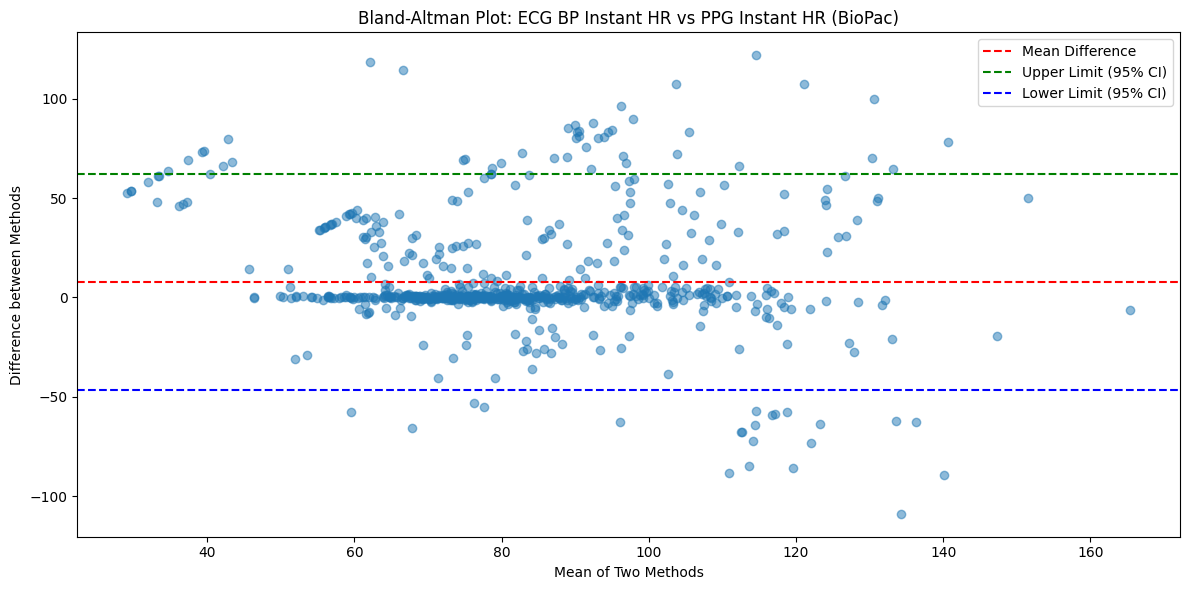

In [20]:
#Q9  ECG vs PPG Instant HR
merged_df = pd.merge_asof(ecg_inst_gt_hr.sort_values('timestamp'), ppg_inst_hr.sort_values('timestamp'), on='timestamp',
                          direction='nearest')
bland_altman_plot(merged_df['hr_x'], merged_df['hr_y'], title='Bland-Altman Plot: ECG BP Instant HR vs PPG Instant HR (BioPac)')


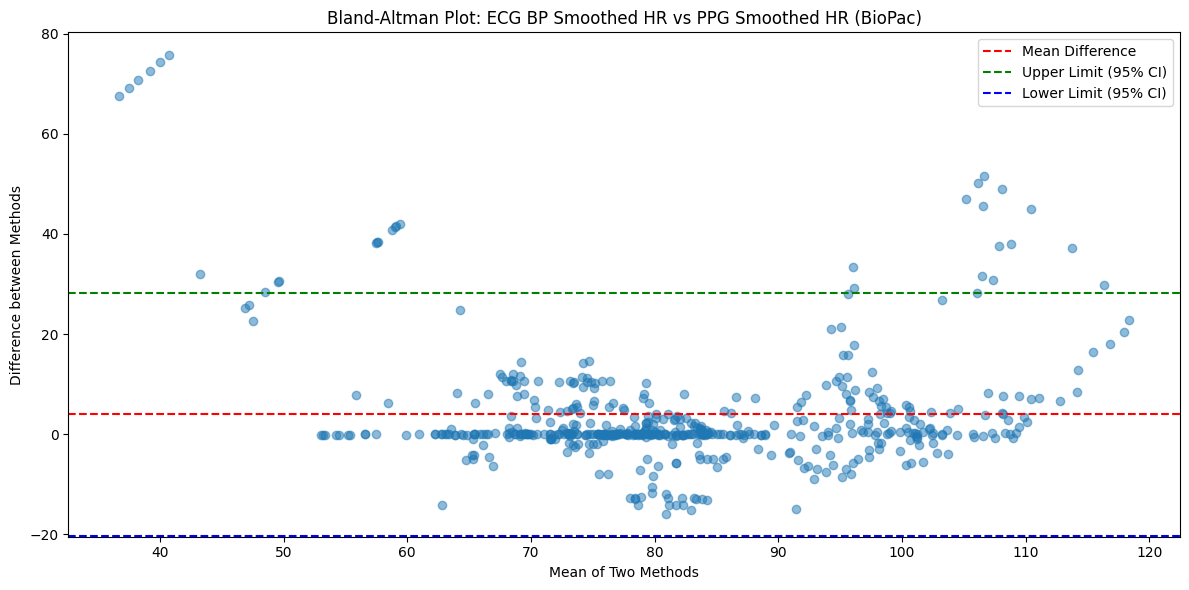

In [21]:
#Q9  ECG vs PPG Smoothed HR (BioPac)
merged_df = pd.merge_asof(ecg_smoothed_gt_hr.sort_values('timestamp'), ppg_smoothed_hr.sort_values('timestamp'), on='timestamp',
                          direction='nearest')
bland_altman_plot(merged_df['smoothed_hr_x'], merged_df['smoothed_hr_y'], title='Bland-Altman Plot: ECG BP Smoothed HR vs PPG Smoothed HR (BioPac)')


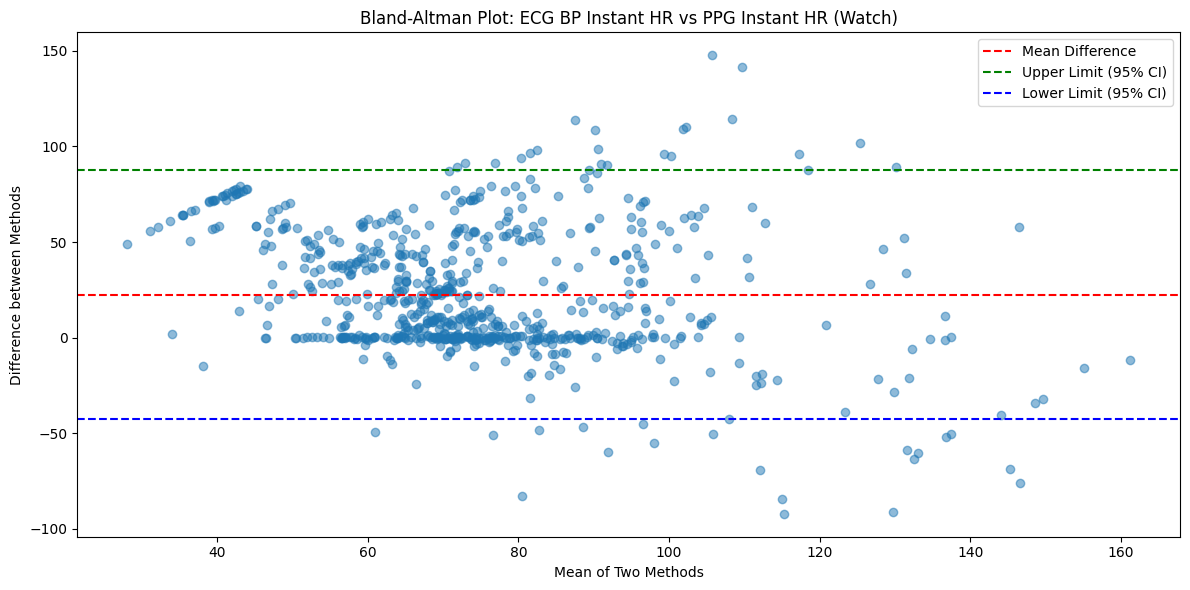

In [22]:
#Q9 ECG vs PPG Instant HR (Watch)
merged_df = pd.merge_asof(ecg_inst_gt_hr.sort_values('timestamp'), watch_ppg_inst_hr.sort_values('timestamp'), on='timestamp',
                          direction='nearest')
bland_altman_plot(merged_df['hr_x'], merged_df['hr_y'], title='Bland-Altman Plot: ECG BP Instant HR vs PPG Instant HR (Watch)')

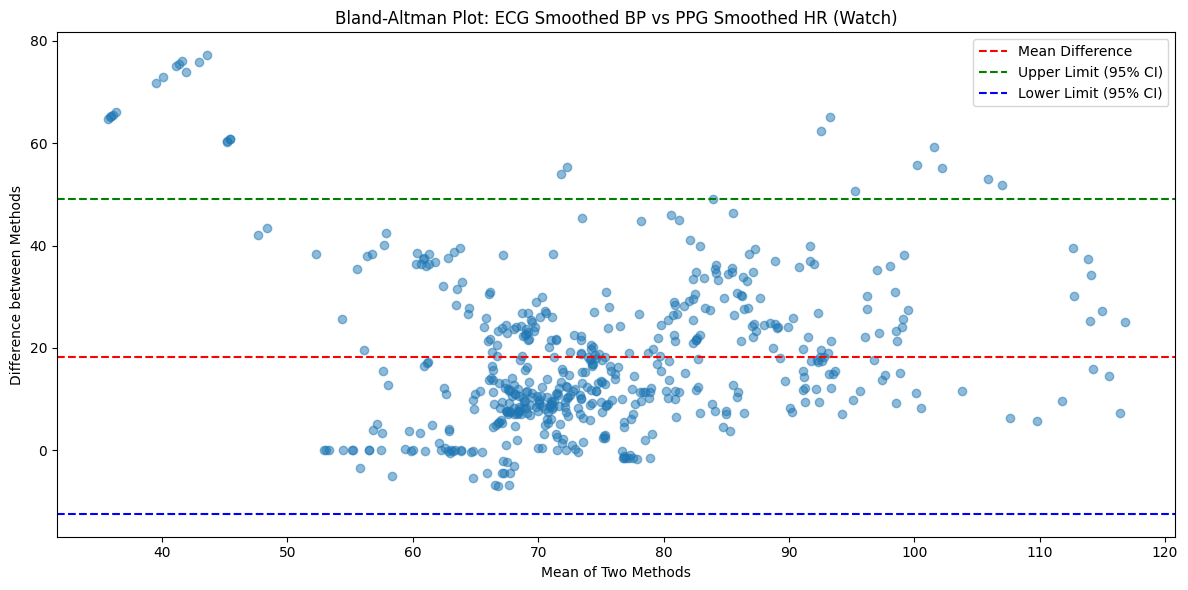

In [23]:
#Q9 ECG vs PPG Smoothed HR (Watch)
merged_df = pd.merge_asof(ecg_smoothed_gt_hr.sort_values('timestamp'), watch_ppg_smoothed_hr.sort_values('timestamp'), on='timestamp',
                          direction='nearest')
bland_altman_plot(merged_df['smoothed_hr_x'], merged_df['smoothed_hr_y'], title='Bland-Altman Plot: ECG Smoothed BP vs PPG Smoothed HR (Watch)')

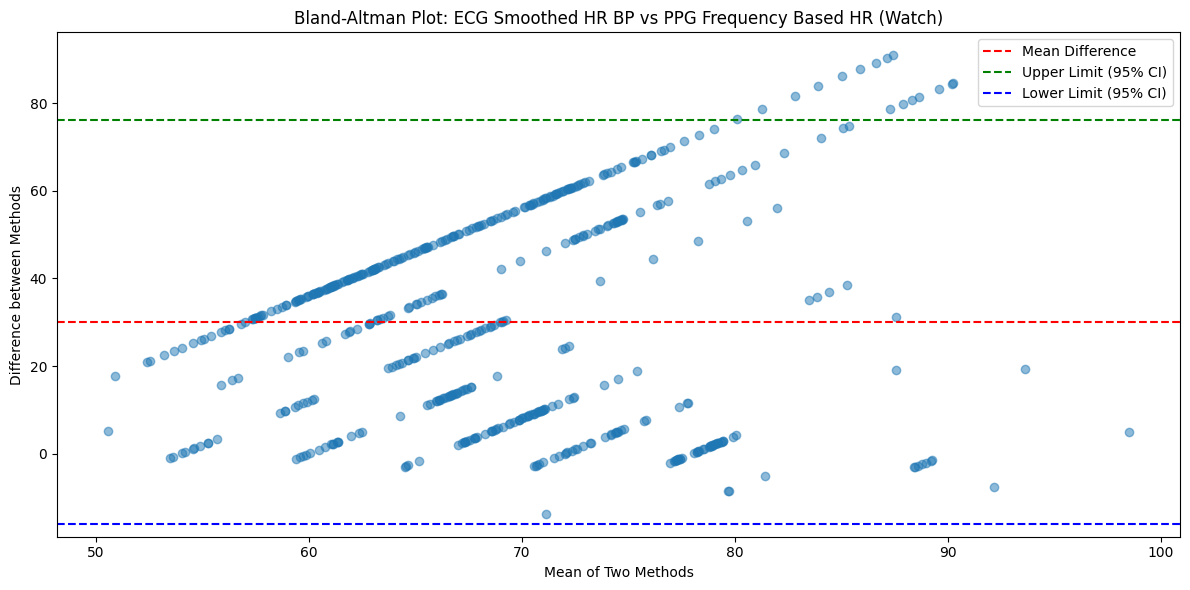

In [24]:
# Q9 ECG vs PPG Frequency Based HR (Watch)
hr_frequency_based = sliding_window_heart_rate(watch_ppg,'PPG' )
merged_df = pd.merge_asof(ecg_smoothed_gt_hr.sort_values('timestamp'), hr_frequency_based.sort_values('timestamp'), on='timestamp',
                          direction='nearest')
merged_df
bland_altman_plot(merged_df['smoothed_hr'], merged_df['hr'], title='Bland-Altman Plot: ECG Smoothed HR BP vs PPG Frequency Based HR (Watch)')

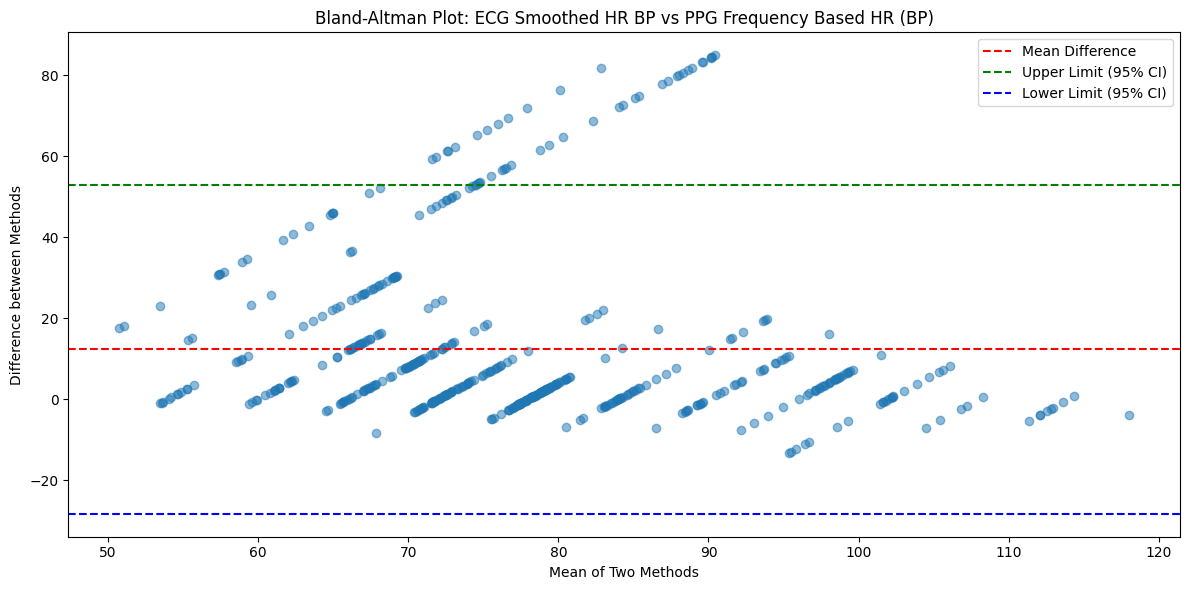

In [25]:
hr_frequency_based = sliding_window_heart_rate(ecg_gt_curve,'PPG' )
merged_df = pd.merge_asof(ecg_smoothed_gt_hr.sort_values('timestamp'), hr_frequency_based.sort_values('timestamp'), on='timestamp', direction='nearest')
merged_df
bland_altman_plot(merged_df['smoothed_hr'], merged_df['hr'], title='Bland-Altman Plot: ECG Smoothed HR BP vs PPG Frequency Based HR (BP)')